In [ ]:
from google.colab import drive
# mount Google Drive
drive.mount('/content/drive')

# paths to PhysioNet 2012 data in Google Drive
google_drive_folder = '/content/drive/MyDrive/physionet2012/'
set_a_directory = f"{google_drive_folder}/set-a"
set_b_directory = f"{google_drive_folder}/set-b"
outcomes_a_file = f"{set_a_directory}/Outcomes-a.txt"
outcomes_b_file = f"{set_b_directory}/Outcomes-b.txt"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_outcomes = pd.read_csv(outcomes_a_file).set_index("RecordID")

patient_id = 139609
patient_file = f"{set_a_directory}/{patient_id}.txt"
df = pd.read_csv(patient_file)

df["Time"] = pd.to_timedelta(df["Time"] + ":00")
df["Hours"] = df["Time"].dt.total_seconds() / 3600.0

df = df.groupby(["Hours","Parameter"], as_index=False).agg({"Value":"sum"})

df_pivot = df.pivot(index="Hours", columns="Parameter", values="Value")

drop_cols = ["RecordID","Age","Gender","Height","ICUType","Weight"]
df_pivot.drop(columns=[c for c in drop_cols if c in df_pivot.columns],
              inplace=True, errors="ignore")

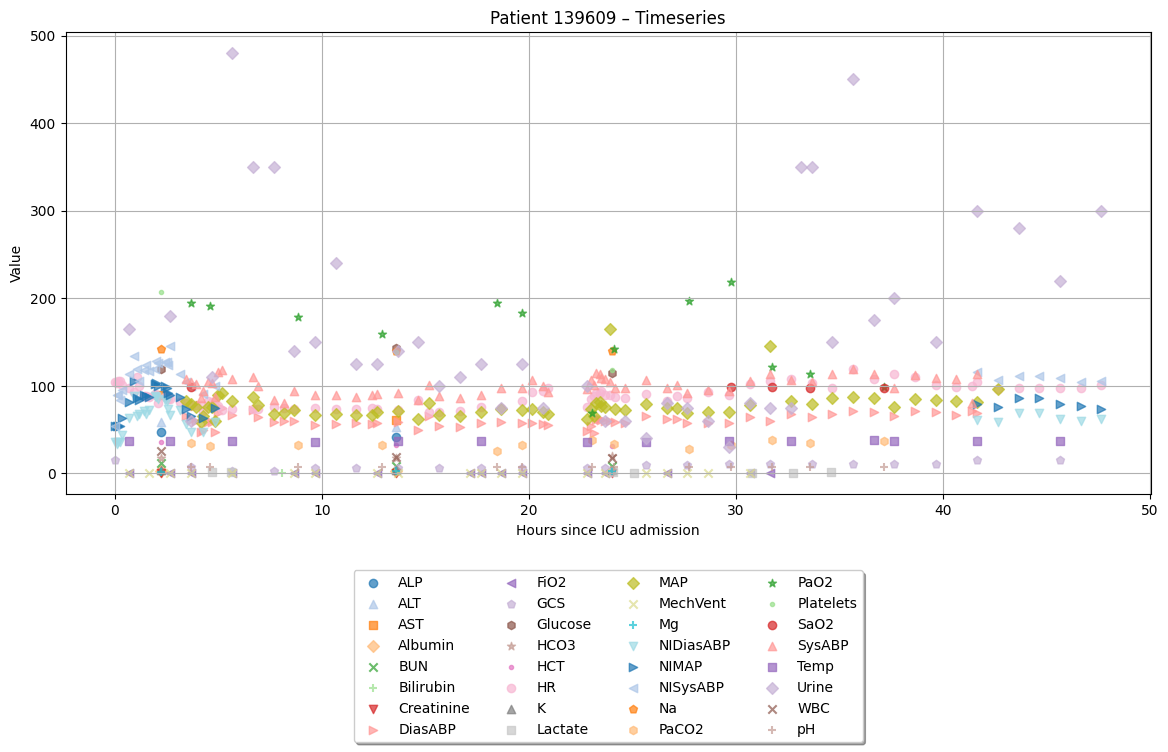

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# index = time (hours), columns = variables

fig, ax = plt.subplots(figsize=(14, 6))

markers = ["o", "^", "s", "D", "x", "+", "v", ">", "<", "p", "h", "*", "."]


colors = plt.cm.tab20.colors
num_vars = len(df_pivot.columns)

for i, col in enumerate(df_pivot.columns):
    marker = markers[i % len(markers)]
    color = colors[i % len(colors)]

    ax.scatter(
        df_pivot.index,
        df_pivot[col],
        label=col,
        color=color,
        marker=marker,
        alpha=0.7
    )
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    fancybox=True,
    shadow=True,
    ncol=4
)
ax.set_title("Patient 139609 – Timeseries")
ax.set_xlabel("Hours since ICU admission")
ax.set_ylabel("Value")
ax.grid(True)